In [27]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

import _syntax_score_helper_function as ga

from _helper_functions import cb
from _helper_functions import zipdf

import _helper_grammar_functions as jsgo

import ast
import statsmodels.api as sm
import pandas as pd 
from sklearn.metrics import (confusion_matrix, 
                           accuracy_score)

import scipy.stats as stats


# syntax features

In [4]:

fn='F05-Syntax-Features/6-real-and-imputed-motifs.pd.df.pickle'
syndf=pd.read_pickle(fn)#.set_index('phrase-key')

syndf.head(2)

,phrase-length,func-odds-ratio,real-data,hyp-func-p-bonf,num-total-seqs,num-active-ens,obs-or-imputed
phrase-key,,,,,,,
ord_ori_spc=g_21_e_24_E,3.0,11.206427,"(63, 34, 7)",3.246130e-29,104.0,63.0,obs
ord_ori_spc=g_13_e_24_E,3.0,8.385350,"(108, 73, 21)",3.208155e-43,202.0,108.0,obs


In [6]:
sigmotifset=set(syndf.index)
list(sigmotifset)[:10]

['ord_ori_spc=G_13_e_25_E',
 'ord_ori_spc=e_23_G_7_G',
 'ord_ori_spc=g_21_e_10_g',
 'ord_ori_spc=e_10_G_8_g',
 'ord_ori_spc=e_9_G_20_g',
 'ord_ori_spc=E_47_g_8_e',
 'ord_ori_spc=e_9_G_15_G',
 'ord_ori_spc=G_35_g_8_e',
 'ord_ori_spc=g_42_G_10_E',
 'ord_ori_spc=e_13_e_17_G']

In [8]:
sigmotifset_withrevcomp=set()

for si in sigmotifset:

    
    resi=ga.revcomp(si.split('=')[-1],'ord_ori_spc')
    resi='ord_ori_spc='+resi

    sigmotifset_withrevcomp.add(si)
    sigmotifset_withrevcomp.add(resi)


# mpra data

In [9]:
# get activity of all variants
fn='01-Calculate-Enhancer-Activity-Levels/02-generated-tables//endf.rescaledPctl_45_85.wtcollapsed.sumRnaDivSumDna-repSum.pd.df.pickle'
mpradf=pd.read_pickle(fn)


In [10]:
mpradf.head(1)

,enhancer-id,enhancer-sites,wt-enhancer-seq,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets
0,Otx-a WT,L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,1.197798,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.848065,"(1, 0)",0



# mapping sequences to syntax features and vice versa

In [37]:
# # structure for data collected
# syn2en2afflist={}
# en2syn2afflist={}

# # options for encoding syntax
# # length=3
# spacing=True

# for length in [2,3]:
#     for seq in mpradf['wt-enhancer-seq']:
    
#         # get full sentence
#         sentence_oos =ga.get_sentence_from_seq(seq,featureTuple=('ord','ori','spc'))
#         sentence_oosa=ga.get_sentence_from_seq(seq,featureTuple=('ord','ori','spc','aff'))
        
#         # get all possible features with and without affinty 
#         allPossibleFeatures_tuplelist_oos=list(ga.get_all_phrases(sentence_oos,spacing,length).keys())
#         allPossibleFeatures_tuplelist_oosa=list(ga.get_all_phrases(sentence_oosa,spacing,length).keys())
        
#         ### map affinity of each site
#         # for all features with and without affinity encoding 
#         for oosai in allPossibleFeatures_tuplelist_oosa:

#             # strip affinity
#             oosi=[]
#             for i in oosai:
#                 if type(i)==str:
#                     i=i.split('.')[0]
#                     oosi.append(i)
#                 else:
#                     oosi.append(i)
#             oosi=tuple(oosi)
            
#             if oosi not in syn2en2afflist:
#                 syn2en2afflist[oosi]={}
#             if seq not in en2syn2afflist:
#                 en2syn2afflist[seq]={}
        
#             syn2en2afflist[oosi][seq]=[]
#             en2syn2afflist[seq][oosi]=[]
        
#             # for each site
#             for si,sai in zip(oosi,oosai):
                
#                 # skip if spacing 
#                 if type(si)==int: continue
        
#                 # ensure the affinity encoding is associated with the same motif
#                 sai_noaff,sai_affonly=sai.split('.')
                
#                 if si!=sai_noaff: 
#                     print(length,si,sai_noaff)
#                     print(oosi)
#                     print(oosai)
#                     raise ValueError('123')
        
#                 # map affinity
#                 syn2en2afflist[oosi][seq].append(sai_affonly)
#                 en2syn2afflist[seq][oosi].append(sai_affonly)

In [44]:
# write the data so you can load the pre-processed file
for d,name in [(syn2en2afflist,'F05-Syntax-Features//syn2en2afflist.pydict.pickle'),(en2syn2afflist,'F05-Syntax-Features//en2syn2afflist.pydict.pickle')]:
    with open(name,'wb') as f:
        pickle.dump(d,f,protocol=pickle.HIGHEST_PROTOCOL)

# load syntax family info

In [16]:
fn='reference-files//OLSName2SyntaxFamily-vary-aff.pydict.pickle'
with open(fn,'rb') as f:
    OLSName2SyntaxFamily=pickle.load(f)


In [17]:
fn='reference-files//OLSEnSeq2Name.pydict.pickle'
with open(fn,'rb') as f:
    OLSEnSeq2Name=pickle.load(f)


In [18]:
fn='reference-files//SyntaxFamily2OLSName-vary-aff.pydict.pickle'
with open(fn,'rb') as f:
    SyntaxFamily2OLSName=pickle.load(f)
    

In [28]:
fn='F03-Syntax-Families/syntax-family-analysis-table-with-permuted-data_numiters=100.pd.df.pickle'
sdf=pd.read_pickle(fn).set_index('syntax-family',drop=False)
sdf.loc[:,'n-func-inert-tuple']=sdf.loc[:,'n-func-inert-tuple'].apply(lambda i: ast.literal_eval(i))


In [29]:
sdf.head()

,syntax-family,n-func,n-inert,n-func-inert-tuple,n-func-inert-tuple-permute-0,n-func-inert-tuple-permute-1,n-func-inert-tuple-permute-2,n-func-inert-tuple-permute-3,n-func-inert-tuple-permute-4,n-func-inert-tuple-permute-5,...,n-func-inert-tuple-permute-90,n-func-inert-tuple-permute-91,n-func-inert-tuple-permute-92,n-func-inert-tuple-permute-93,n-func-inert-tuple-permute-94,n-func-inert-tuple-permute-95,n-func-inert-tuple-permute-96,n-func-inert-tuple-permute-97,n-func-inert-tuple-permute-98,n-func-inert-tuple-permute-99
syntax-family,,,,,,,,,,,,,,,,,,,,,
L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6,L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6,4,2,"(4, 2)","(2, 3)","(2, 5)","(4, 3)","(3, 3)","(1, 6)","(2, 4)",...,"(0, 3)","(4, 2)","(2, 3)","(3, 2)","(5, 2)","(4, 2)","(1, 6)","(1, 3)","(1, 1)","(1, 6)"
L1-GF-L2-EF-L3-EF-L4-GR-L5-GF-L6,L1-GF-L2-EF-L3-EF-L4-GR-L5-GF-L6,2,4,"(2, 4)","(2, 4)","(2, 6)","(1, 5)","(2, 2)","(1, 3)","(2, 3)",...,"(5, 0)","(1, 3)","(1, 4)","(1, 6)","(2, 3)","(3, 5)","(2, 2)","(0, 3)","(2, 4)","(1, 5)"
L1-GR-L2-EF-L3-EF-L4-GF-L5-GF-L6,L1-GR-L2-EF-L3-EF-L4-GF-L5-GF-L6,1,4,"(1, 4)","(2, 4)","(2, 2)","(3, 3)","(2, 2)","(1, 7)","(3, 4)",...,"(2, 7)","(0, 2)","(4, 2)","(2, 3)","(1, 6)","(2, 2)","(1, 2)","(1, 2)","(0, 6)","(2, 4)"
L1-GR-L2-EF-L3-EF-L4-GR-L5-GR-L6,L1-GR-L2-EF-L3-EF-L4-GR-L5-GR-L6,3,1,"(3, 1)","(3, 4)","(2, 5)","(4, 5)","(2, 2)","(2, 2)","(4, 3)",...,"(0, 2)","(1, 5)","(4, 4)","(1, 6)","(4, 4)","(2, 5)","(2, 2)","(1, 1)","(0, 5)","(0, 5)"
L1-GR-L2-ER-L3-EF-L4-GR-L5-GF-L6,L1-GR-L2-ER-L3-EF-L4-GR-L5-GF-L6,4,1,"(4, 1)","(2, 3)","(5, 6)","(3, 6)","(0, 6)","(2, 7)","(1, 4)",...,"(4, 2)","(1, 7)","(3, 3)","(2, 4)","(0, 4)","(2, 5)","(2, 3)","(3, 2)","(1, 5)","(1, 2)"


In [30]:
len(sdf)

38400

In [32]:
mpradf['bin']=mpradf['enhancer-sites'].apply(lambda sites: sdf.at[OLSName2SyntaxFamily[sites],'n-func-inert-tuple'])


In [33]:
fn='reference-files/syntax-fam-Bin2Annotation.pydict.pickle'
with open(fn,'rb') as f:
    Bin2Annotation=pickle.load(f)

In [34]:
mpradf['bin-annotation']=mpradf['bin'].apply(lambda b: Bin2Annotation[b])

# what are average number of syn motifs in each family group 

In [40]:
binanno2numsyntaxfeats={}
for enid,en,binanno in zipdf(mpradf,['enhancer-id','wt-enhancer-seq','bin-annotation']):

    

    allsyntaxfeats=list(en2syn2afflist[en].keys())
    allsyntaxfeats=['ord_ori_spc='+'_'.join([str(i) for i in si]) for si in allsyntaxfeats]
    allsyntaxfeats=set(allsyntaxfeats)
    
    allSIGsyntaxfeats = sigmotifset_withrevcomp &  allsyntaxfeats

    if binanno not in binanno2numsyntaxfeats:
        binanno2numsyntaxfeats[binanno]=[]

    binanno2numsyntaxfeats[binanno].append(len(allSIGsyntaxfeats))


Text(0, 0.5, 'Number of significant \nsyntax features')

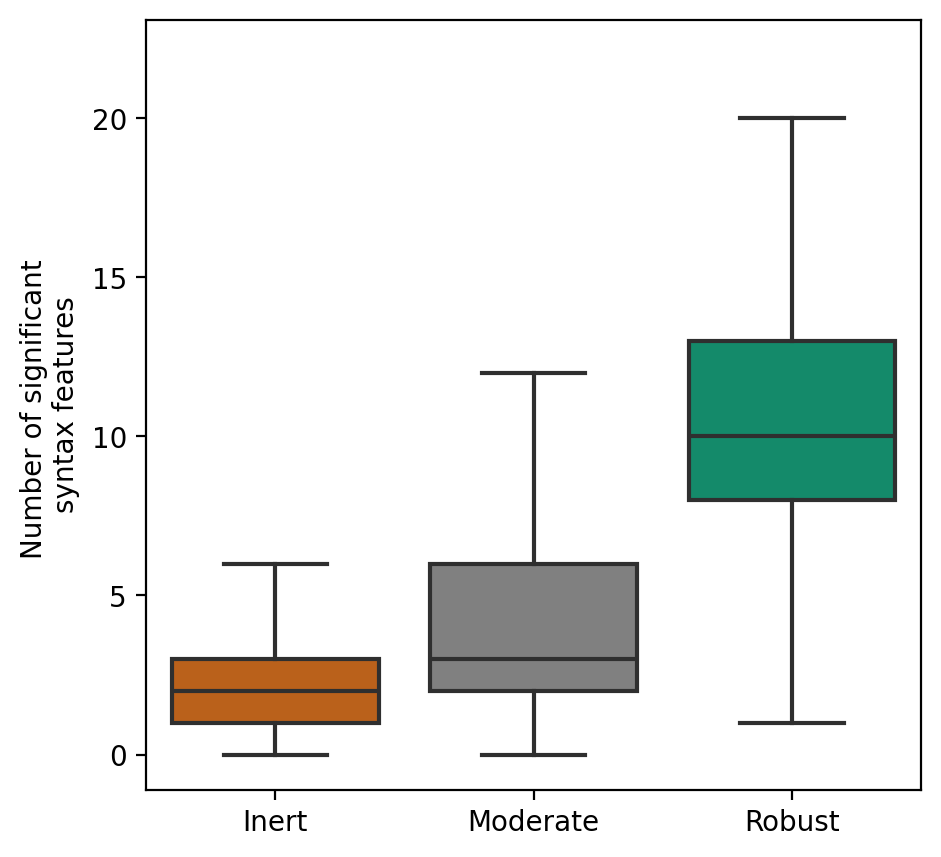

In [43]:
fig,ax=plt.subplots(1,figsize=(5,5),dpi=200)

sns.boxplot(data=[binanno2numsyntaxfeats[bi] for bi in ['Inert','Moderate','Robust']],palette=[cb['red'],'grey',cb['green']],fliersize=0)

ax.set_xticklabels(['Inert','Moderate','Robust'])
ax.set_ylabel('Number of significant \nsyntax features')

# out=f'000-manuscript-figs/13a_MAT_20240322_Grammar-Matrix-Dependencies__avg-num-syntax-motifs-per-syntax-fam.svg'
# plt.savefig(out,format='svg',transparent=True)